In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

In [ ]:
!pip install librosa tensorflow scikit-learn

In [ ]:
import librosa
import os
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
audio_path = "/content/drive/MyDrive/Emotion_Project/datasets/TESS/TESS Toronto emotional speech set data"

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Emotion_Project/datasets/TESS/archive.zip"

extract_path = "/content/drive/MyDrive/Emotion_Project/datasets/TESS"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['humanvalues.pptx', 'CSE C', 'Untitled presentation (7).gslides', 'Untitled presentation (6).gslides', 'Ppt', 'Untitled presentation (5).gslides', 'IMG-20240404-WA0008.jpg', 'IMG-20240416-WA0021.jpg', 'IMG-20240416-WA0041.jpg', 'IMG-20240416-WA0043.jpg', 'Untitled form (1).gform', 'Untitled form.gform', 'Untitled form (Responses).gsheet', 'contact.gdoc', 'Untitled document (47).gdoc', 'Untitled document (46).gdoc', 'Untitled document (45).gdoc', 'Untitled document (44).gdoc', 'Untitled document (43).gdoc', 'Untitled document (42).gdoc', 'Untitled document (41).gdoc', 'Untitled document (40).gdoc', 'Circular queue implementation without using mod operator.gdoc', 'Circular queues with mod operator.gdoc', 'PATTERN MATCHING USING KMP ALGORITHM AND LPS.gdoc', 'Spiral form.gdoc', 'DS QUIZ 9.gdoc', 'sdc (1).gdoc', 'sdc.gdoc', 'Untitled document (39).gdoc', 'program to display cse on 7 seg (6).gdoc', 'Untitled document (38).gdoc', 'Untitled document (37).gdoc', 'Untitled document (36).gdoc', 

In [ ]:
print(os.listdir("/content/drive/MyDrive/Emotion_Project"))

['datasets', 'notebooks', 'saved_models', 'results', 'report']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Emotion_Project/datasets"))


['TESS', 'text_dataset']


In [ ]:
print(os.listdir("/content/drive/MyDrive/Emotion_Project/datasets/TESS"))

['archive.zip', 'TESS Toronto emotional speech set data', 'tess toronto emotional speech set data']


In [ ]:
audio_path = "/content/drive/MyDrive/Emotion_Project/datasets/TESS/TESS Toronto emotional speech set data"

In [ ]:
import os

folders = os.listdir(audio_path)

print(folders[:10])

['OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral', 'YAF_angry', 'YAF_disgust', 'YAF_fear']


In [ ]:
folder = folders[0]

folder_path = os.path.join(audio_path, folder)

files = os.listdir(folder_path)

print(files[:5])

['OAF_back_fear.wav', 'OAF_bar_fear.wav', 'OAF_base_fear.wav', 'OAF_bath_fear.wav', 'OAF_bean_fear.wav']


In [ ]:
import librosa

sample_file = files[0]

sample_path = os.path.join(folder_path, sample_file)

signal, sr = librosa.load(sample_path, sr=22050)

print("Sampling Rate:", sr)
print("Signal Shape:", signal.shape)

Sampling Rate: 22050
Signal Shape: (38084,)


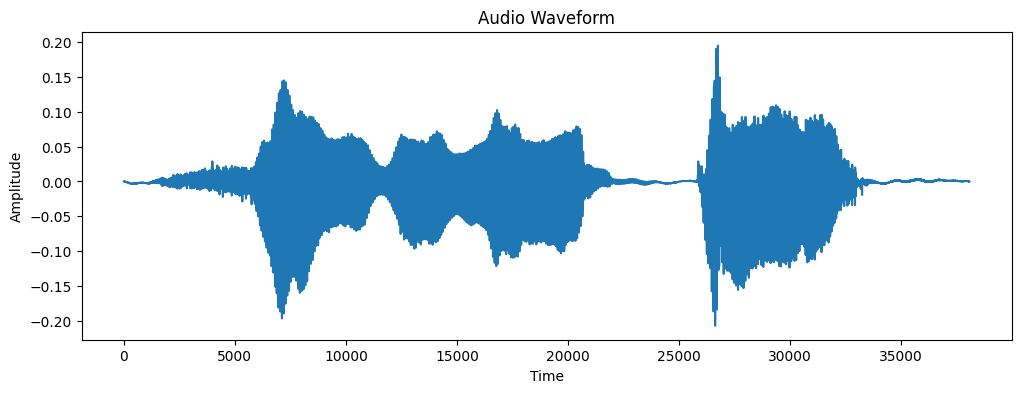

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(signal)

plt.title("Audio Waveform")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

In [ ]:
trimmed_signal, _ = librosa.effects.trim(signal)

print("Original Length:", len(signal))
print("Trimmed Length:", len(trimmed_signal))

Original Length: 38084
Trimmed Length: 38084


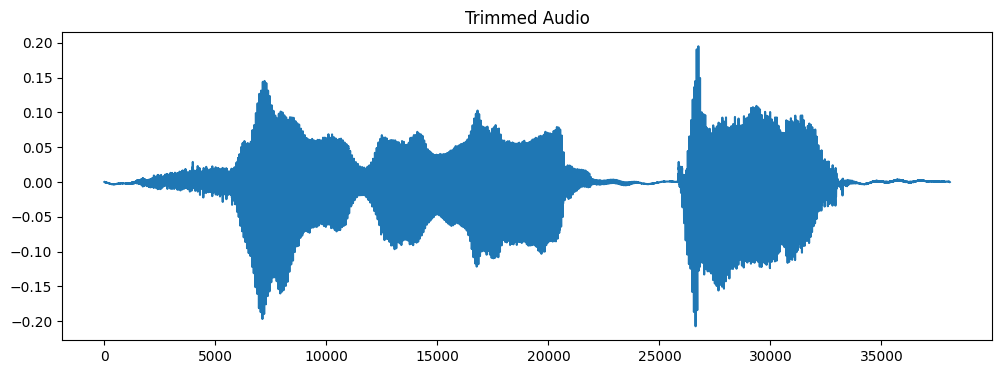

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(trimmed_signal)

plt.title("Trimmed Audio")

plt.show()

In [ ]:
normalized_signal = trimmed_signal / np.max(np.abs(trimmed_signal))

In [ ]:
max_len = 3 * sr

print(max_len)

66150


In [ ]:
import numpy as np

if len(normalized_signal) < max_len:

    padded_signal = np.pad(
        normalized_signal,
        (0, max_len - len(normalized_signal))
    )

else:

    padded_signal = normalized_signal[:max_len]

print(len(padded_signal))

66150


In [ ]:
mfcc = librosa.feature.mfcc(
    y=padded_signal,
    sr=sr,
    n_mfcc=40
)

In [ ]:
mfcc = mfcc.T

print(mfcc.shape)

(130, 40)


In [ ]:
import librosa.display

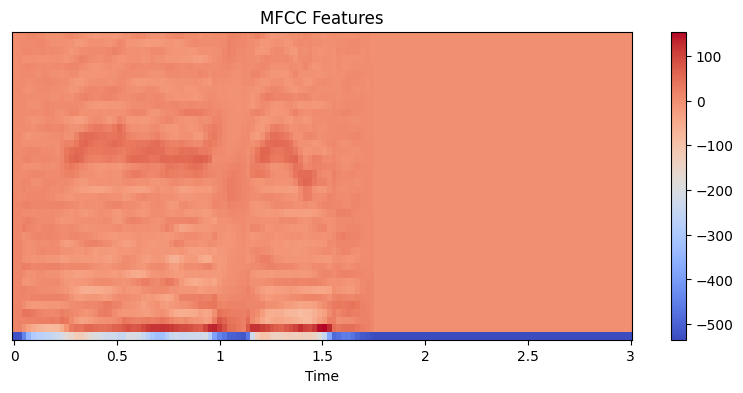

In [ ]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc.T,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

Process Entire Dataset

In [ ]:
X = []
y = []

In [ ]:
emotions = os.listdir(audio_path)

print(emotions)

['OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral', 'YAF_angry', 'YAF_disgust', 'YAF_fear', 'YAF_happy', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_sad']


In [ ]:
for emotion_folder in emotions:

    folder_path = os.path.join(audio_path, emotion_folder)

    audio_files = os.listdir(folder_path)

    for file in audio_files:

        file_path = os.path.join(folder_path, file)

        try:

            signal, sr = librosa.load(file_path, sr=22050)

            # Trim silence
            signal, _ = librosa.effects.trim(signal)

            # Normalize
            signal = signal / np.max(np.abs(signal))

            # Fixed length
            max_len = 3 * sr

            if len(signal) < max_len:

                signal = np.pad(
                    signal,
                    (0, max_len - len(signal))
                )

            else:

                signal = signal[:max_len]


            # MFCC extraction
            mfcc = librosa.feature.mfcc(
                y=signal,
                sr=sr,
                n_mfcc=40
            )

            mfcc = mfcc.T


            # Store features
            X.append(mfcc)


            # Extract label
            label = emotion_folder.split('_')[1]

            y.append(label)

        except Exception as e:

            print("Error processing:", file)
            print(e)

In [ ]:
X = np.array(X)

y = np.array(y)

print(X.shape)
print(y.shape)

(2800, 130, 40)
(2800,)


In [ ]:
np.save(
    "/content/drive/MyDrive/Emotion_Project/saved_models/X_speech.npy",
    X
)

In [ ]:
np.save(
    "/content/drive/MyDrive/Emotion_Project/saved_models/y_speech.npy",
    y
)